# **Unlocking the ❤️: A Comprehensive Exploration of Predictive Insights for Heart Disease 📊🔍**

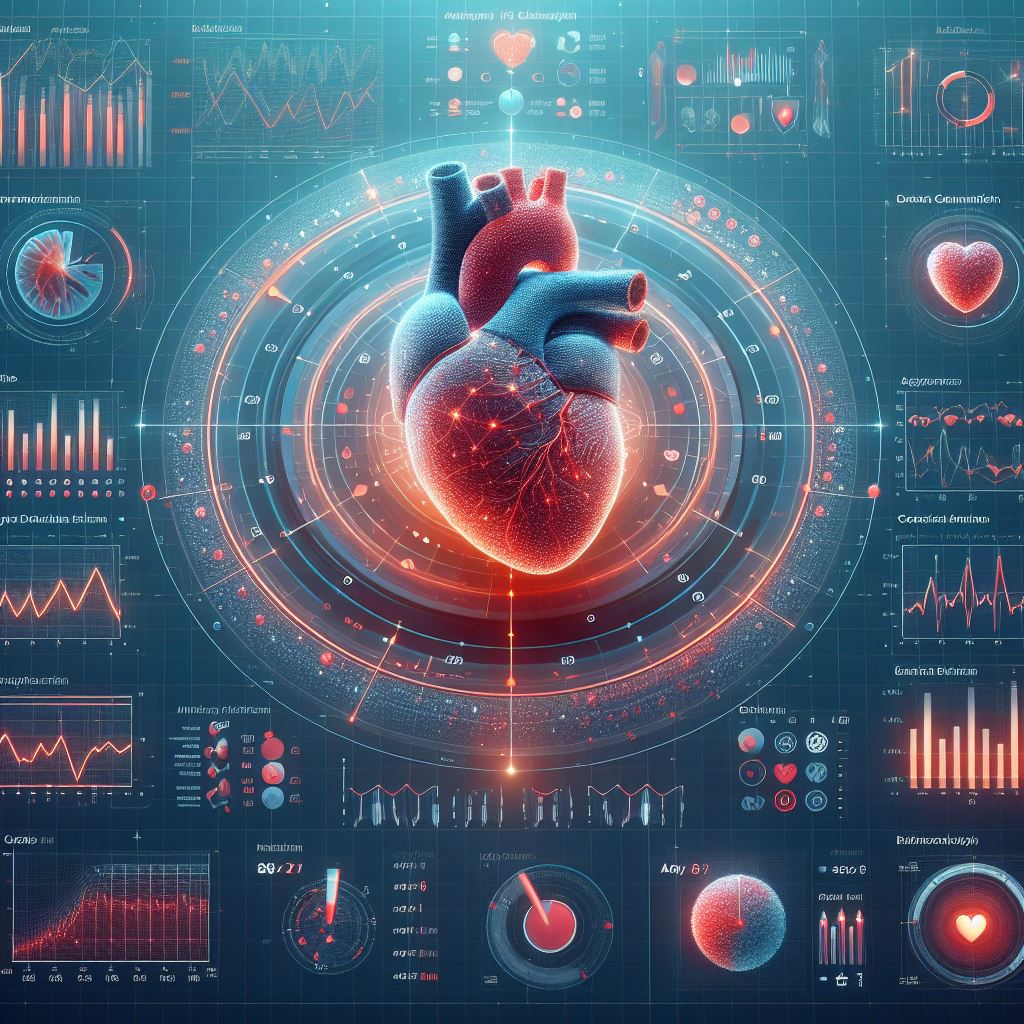

# Title: **Heart Disease Prediction**

## About The Author

**Project Name**:      Heart Disease Prediction

**Author Name**:       Saman Fatima 

*Lets Connect to learn and bring a positive change in the industry* 

[`Github`](https://github.com/SamanFatima7)

[`kaggle`](https://www.kaggle.com/samanfatima7)

[`Linkedin`](https://www.linkedin.com/in/saman-fatima-datascience/)

[`Twitter`](https://twitter.com/SamanFatima9106)

#  Meta-Data (About Dataset)
## Context
This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

### Content
#### Column Descriptions:
* `id` (Unique id for each patient)
* `age` (Age of the patient in years)
* `origin` (place of study)
* `sex` (Male/Female)
* `cp` chest pain type 
  1. typical angina, 
  2. atypical angina, 
  3. non-anginal, 
  4. asymptomatic
* `trestbps` resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* `chol` (serum cholesterol in mg/dl)
* `fbs` (if fasting blood sugar > 120 mg/dl)
* `restecg` (resting electrocardiographic results)
* -- `Values`: [normal, stt abnormality, lv hypertrophy]
* `thalach`: maximum heart rate achieved
* `exang`: exercise-induced angina (True/ False)
* `oldpeak`: ST depression induced by exercise relative to rest
* `slope`: the slope of the peak exercise ST segment
* `ca`: number of major vessels (0-3) colored by fluoroscopy
* `thal`: [normal; fixed defect; reversible defect]
* `num`: the predicted attribute

### Acknowledgements
#### Creators:
* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
* University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
* University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
* V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.
#### Relevant Papers:
* Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310. 
* David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database." 
* Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61.
#### Citation Request:
The authors of the databases have requested that any publications resulting from the use of the data include the names of the principal investigator responsible for the data collection at each institution. 

**They would be:**

* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
* University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
* University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
* V.A. Medical Center, Long Beach and Cleveland Clinic Foundation:Robert Detrano, M.D., Ph.D.

# Importing Libraries

_Let's start the project by impoprting all the libraries that we will need in this project.
_

In [ ]:
# import libraries

# 1. to handle the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor, BaggingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report ,mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb


# ignore warnings   
import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [ ]:
# load the data from csv file placed locally in our pc
df = pd.read_csv('/kaggle/input/heart-disease-data/heart_disease_uci.csv')

# print the first 5 rows of the dataframe
df.head()

---
# **<font color="#FFA500">Exploratory Data Analysis (EDA)</font>**
----


### Exploring each Column

In [ ]:
# exploring the datatype of each column
df.info()

In [ ]:
# this data contains 920 rows and 16 columns 
df.shape

----
# **<font color="#FFA500">Dealing with Id Column</font>**
---

In [ ]:
# id column
df['id'].min(), df['id'].max()

- Id is telling that total number of people in this dataset are 920 

---
# **<font color="#FFA500">Dealing With Age Column</font>**
---


In [ ]:
# age column minimm and maximum 
df['age'].min(), df['age'].max()

- The range of age is 28 to 77

In [ ]:
# let's summarie the age column
df['age'].describe()

- The average age is 53 

In [ ]:
# draw a histogram to see the distribution of age column
sns.histplot(df['age'], kde=True)

In [ ]:
# plot the mean, median and mode of age column using sns
sns.histplot(df['age'], kde=True)
plt.axvline(df['age'].mean(), color='red')
plt.axvline(df['age'].median(), color='green')
plt.axvline(df['age'].mode()[0], color='blue')

# print the value of mean, median and mode of age column
print('Mean:', df['age'].mean())
print('Median:', df['age'].median())
print('Mode:', df['age'].mode()[0])

> Let's explore the gender based distribution of the dataset for age column.

In [ ]:
# plot the histogram of age column using plotly and coloring this by sex

fig = px.histogram(data_frame=df, x='age', color='sex')
fig.show()

_**Observations**_
- 70 males in age range between 54-55 
- 22 females in the age range between 54-55
- So it means that according to this dataset males are getting heart disease more frequently then females 

---
# **<font color="#FFA500">Dealing with Sex Column</font>**
---


In [ ]:
# find the values of sex column
df['sex'].value_counts()

In [ ]:
# calculate the percentages of male and female value counts in the data
male_count = 726
female_count = 194
total_count = male_count + female_count

# calculate percentages
male_percentage = (male_count / total_count) * 100
female_percentage = (female_count / total_count) * 100

# display the results
print(f"Male percentage in the data: {male_percentage:.2f}%")
print(f"Female Percentage in the data: {female_percentage:.2f}%")

# difference
difference_percentage = ((male_count - female_count) / female_count) * 100
print(f"Males are {difference_percentage:.2f}% more than females in the data.")

In [ ]:
# find the values count of age column grouping by sex column
df.groupby('sex')['age'].value_counts()

_**Observations:**_
* Males are 726 Females are 194
* Male percentage in the data: 78.91%
* Female Percentage in the data: 21.09%
* Males are 274.23% more than females in the data.

----
# **<font color="#FFA500">Dealing with Dataset Column</font>**
---


In [ ]:
# find the unique values in dataset column
df['dataset'].unique()

In [ ]:
# find unique values count in dataset column
df['dataset'].value_counts()

In [ ]:
#check from wchich place male of felae were 
fig = px.bar(df, x='dataset', color='sex')
fig.show()

# print the values count of dataset column grouped by sex
print(df.groupby('sex')['dataset'].value_counts())

In [ ]:
# make a plot of age column using plotly and coloring this by dataset column
fig = px.histogram(data_frame=df, x='age', color='dataset')
fig.show()

# print the mean median and mode of age column grouped by dataset column
print(f"Mean of Data Set: {df.groupby('dataset')['age'].mean()}")
print("-------------------------------------")
print(f"Median of Data Set: {df.groupby('dataset')['age'].median()}")
print("-------------------------------------")
print(f"Mode of Data Set: {df.groupby('dataset')['age'].agg(pd.Series.mode)}")
print("-------------------------------------")


_**Observations**_

_*These are the numbers of people from 4 different places_

| Location        | Total |
|-----------------|-------|
| Cleveland       | 304   |
| Hungary         | 293   |
| VA Long Beach   | 200   |
| Switzerland     | 123   |


_*On the basis of Gender these are the number of males and females from different places_

| Gender | Location        | Total |
|--------|-----------------|-------|
| Female | Cleveland       | 97    |
|        | Hungary         | 81    |
|        | Switzerland     | 10    |
|        | VA Long Beach   | 6     |
| Male   | Hungary         | 212   |
|        | Cleveland       | 207   |
|        | VA Long Beach   | 194   |
|        | Switzerland     | 113   |

_The most frequent age group from each place_

| Location        |  Age  |
|-----------------|-------|
| Cleveland       | 58    |
| Hungary         | 54    |
| Switzerland     | 61    |
| VA Long Beach   | 62    |


---
# **<font color="#FFA500">Dealing with Cp Column</font>**
----


**Asymptomatic:**
*Asymptomatic* means that individuals do not exhibit the typical symptoms associated with heart problems, such as chest pain.

**Non-Anginal Chest Pain:**
*Non-anginal* chest pain refers to discomfort that deviates from the typical pattern of angina. It may not be triggered by physical activity and can have various characteristics.

**Atypical Angina:**
*Atypical angina* maintains a connection to the heart but diverges from the classic symptoms commonly associated with typical angina. It may have different qualities compared to the usual anginal pain.

**Angina and Heart Disease:**
*Angina* is closely entwined with heart disease. It serves as a symptom, signaling an underlying issue with the blood supply to the heart. Typically associated with coronary artery disease (CAD), angina indicates a potential lack of oxygen and nutrients reaching the heart muscle, urging individuals to seek prompt medical attention.

In [ ]:
# value count of cp column
df['cp'].value_counts()

In [ ]:
# count plot of cp column by sex column
sns.countplot(df, x='cp', hue='sex')

In [ ]:
# count plot of cp column by dataset column
sns.countplot(df, x='cp', hue='dataset')

In [ ]:
print(df.groupby('cp')['dataset'].value_counts())

In [ ]:
# draw the plot of age column grouped by cp column using plotly
fig = px.histogram(data_frame=df, x='age', color='cp')
fig.show()

In [ ]:
print(df.groupby('sex')['cp'].value_counts())

> **_Observations_**

| Condition         | Count | Description                                                                                          |
|-------------------|-------|------------------------------------------------------------------------------------------------------|
| Asymptomatic      | 496   | Nearly 500 people showed no typical signs of heart problems, like chest pain.                         |
| Non-Anginal       | 204   | About 200 people experienced chest discomfort, not the typical pain associated with heart issues.      |
| Atypical Angina   | 174   | In 174 cases, heart-related symptoms weren't the classic ones you'd expect with typical heart pain.   |
| Typical Angina    | 46    | Only 46 people had the classic chest pain often associated with heart problems.                        |

_**Observations Based on Place and Number of People with Chest Pain**_

| Location          | Count | Description                                                                                              |
|-------------------|-------|----------------------------------------------------------------------------------------------------------|
| Asymptomatic      |       |                                                                                                          |
| - Cleveland        | 144   | 144 people had heart issues but felt no usual signs.                                                     |
| - VA Long Beach    | 131   | 131 people had heart issues without noticeable symptoms.                                                 |
| - Hungary          | 123   | 123 people had heart issues without showing symptoms.                                                    |
| - Switzerland      | 98    | 98 people had heart issues without typical signs.                                                        |
| Atypical Angina   |       |                                                                                                          |
| - Hungary          | 105   | 105 people had different heart symptoms.                                                                 |
| - Cleveland        | 51    | 51 people had heart symptoms different from the usual.                                                   |
| - VA Long Beach    | 14    | 14 people had atypical heart symptoms.                                                                   |
| - Switzerland      | 4     | 4 people had different heart symptoms.                                                                  |
| Non-Anginal       |       |                                                                                                          |
| - Cleveland        | 86    | 86 people had chest discomfort without typical heart pain.                                               |
| - Hungary          | 54    | 54 people had chest discomfort without typical heart pain.                                               |
| - VA Long Beach    | 47    | 47 people had different chest discomfort.                                                               |
| - Switzerland      | 17    | 17 people had chest discomfort without typical heart pain.                                              |
| Typical Angina    |       |                                                                                                          |
| - Cleveland        | 23    | 23 people had classic chest pain linked to heart problems.                                               |
| - Hungary          | 11    | 11 people had typical chest pain linked to heart issues.                                                 |
| - VA Long Beach    | 8     | 8 people had classic chest pain related to heart problems.                                               |
| - Switzerland      | 4     | 4 people had classic chest pain linked to heart issues.                                                  |

---
# **<font color="#FFA500">Dealing with Trestbps Column</font>**
---

The normal resting blood pressure is 120/80 mm Hg.

In [ ]:
# find the value counts of trestbps column
df['trestbps'].describe()

In [ ]:
df['trestbps'].min()

- It is impossible to have a Blood Pressure at 0 so we are going to remove columns containing Value 0 and replacing it with Null values later on we will deal with missing values

In [ ]:
df = df[df['trestbps'] != 0]


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='trestbps', hue='dataset', palette='viridis', s=80)

plt.title('Scatter Plot of Age vs Trestbps')
plt.xlabel('Age')
plt.ylabel('Trestbps')
plt.legend(title='Dataset Type', loc='upper right', bbox_to_anchor=(1.2, 1))

plt.show()

In [ ]:
# create a histplot of trestbps column
sns.histplot(df['trestbps'], kde=True)

> _**Observations**_

- The range of Blood Pressure is now from 80 to 200 which is possible

---
# **<font color="#FFA500">Exploring chol , fbs, restecg, thalch, exang, oldpeak, slope, ca, thal</font>**
----


In [ ]:
df['restecg'].unique()

In [ ]:
df['restecg'] = df['restecg'].str.replace('-', '')

In [ ]:
# Define the columns you want to explore
columns_to_explore = ['chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# Display datatype, value counts, and other insights for each column
for column in columns_to_explore:
    print(f"Column: {column}")
    print(f"Datatype: {df[column].dtype}")
    print(f"Value Counts:\n{df[column].value_counts()}\n")
    print(f"Number of unique values: {df[column].nunique()}")
    if df[column].dtype == 'object':
        print(f"Top value: {df[column].mode()[0]}")
    else:
        print(f"Mean: {df[column].mean()}")
        print(f"Min: {df[column].min()}")
        print(f"Max: {df[column].max()}")
    print("-" * 50)

# Additional insights (mean, min, max, etc.) for numerical columns
numerical_columns = ['chol', 'trestbps', 'thalch', 'oldpeak', 'ca']

print("Additional insights for numerical columns:")
print(df[numerical_columns].describe())

# Additional insights for categorical columns
categorical_columns = ['fbs', 'restecg', 'exang', 'slope', 'thal']

print("\nAdditional insights for categorical columns:")
for column in categorical_columns:
    print(f"Column: {column}")
    print(f"Unique values: {df[column].unique()}")
    print("-" * 50)



> _**Observations**_

- If the `ca` value is 0, it means there are no significant problems in the major blood vessels. It's like saying everything looks good in terms of how blood is flowing through the big arteries in the heart.

- The `thalch` variable typically represents the maximum heart rate achieved during exercise. If it's 60, it is the lowest number, indicating correct information.

- Cholesterol is an essential component of cell membranes and a precursor for certain hormones, so having a cholesterol level of exactly 0 is not consistent with normal physiological functioning. It's very rare and almost impossible.

- Need to impute Cholesterol.
- According to my observation, there is no need to remove zeros in `ca Column` because it makes sense to the data.


In [ ]:
df.columns

---
# **<font color="#FFA500">Dealing with Missing Values</font>**
----


We are going to make a function to deal with missing values.

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()
missing_data_cols

**This function imputes missing values in Categorical columns**

*  `Step 1:` Separate rows with missing and non-missing values for the target column
*  `Step 2:` Extract features (X) and target variable (y) for non-missing values
*  `Step 3:` Extract other missing columns for later imputation
*  `Step 4:` Encode categorical columns using LabelEncoder
*  `Step 5:` Encode the target column if it is a boolean type
*  `Step 6:` Initialize IterativeImputer with RandomForestRegressor as the estimator
*  `Step 7:` Impute other missing columns in the dataset
*  `Step 8:` Split the data into training and testing sets
*  `Step 9:` Train a RandomForestClassifier to predict missing values in the target column
*  `Step 10:` Predict missing values and calculate accuracy
*  `Step 11:` Prepare the dataset with missing values for the final imputation
*  `Step 12:` Impute missing values in the target column for the original missing data
*  `Step 13:` Predict missing values in the target column
*  `Step 14:` Combine the imputed data with the original dataset


**This function imputes missing values in continuous columns**
  
*  `Step 1:` Separate rows with missing and non-missing values for the target column
*  `Step 2:` Extract features (X) and target variable (y) for non-missing values
*  `Step 3:` Extract other missing columns for later imputation
*  `Step 4:` Encode categorical columns using LabelEncoder
*  `Step 5: `Initialize IterativeImputer with RandomForestRegressor as the estimator
*  `Step 6:` Impute other missing columns in the dataset
*  `Step 7:` Split the data into training and testing sets
*  `Step 8:` Train a RandomForestRegressor to predict missing values in the target column
* ` Step 9:` Predict missing values and calculate performance metrics


In [ ]:
categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex', 'num']
bool_cols = ['fbs', 'exang']
numeric_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

In [ ]:
# This function imputes missing values in categorical columnsdef impute_categorical_missing_data(passed_col):
    
def impute_categorical_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)
        
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])
    
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", mean_squared_error(y_test, y_pred, squared=False), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]


In [ ]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

In [ ]:
# remove warning
import warnings
warnings.filterwarnings('ignore')

# impute missing values using our functions
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df[col].isnull().sum() / len(df)) * 100, 2))+"%")
    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        df[col] = impute_continuous_missing_data(col)
    else:
        pass

In [ ]:
df.isnull().sum()

----
# **<font color="#FFA500">Dealing with Outliers</font>**
---


In [ ]:
# create box plots for all numeric columns using for loop and subplot
numeric_columns = df.select_dtypes(include=['number']).columns

# Create box plots for all numeric columns using a for loop
for column in numeric_columns:
    fig = px.box(df, y=column, title=f'Box Plot for {column}')
    fig.show()

### - **We have seen some outliers so i am going to use z score method with a threshold 2.8 because at this threshhold test_accuracy and cross validation scores improve**

In [ ]:
import pandas as pd
from scipy import stats

# Sample DataFrame
# Assume your DataFrame is named 'df'
# df = ...

# Define the columns to check for outliers
columns_to_check = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# Calculate Z-scores for the specified columns
z_scores = np.abs(stats.zscore(df[columns_to_check]))

# Define a Z-score threshold for outlier detection (you can adjust this threshold)
z_score_threshold = 2.8

# Identify outliers using the threshold
outliers = (z_scores > z_score_threshold).any(axis=1)

# Display the rows containing outliers
print("Rows with outliers:")
print(df[outliers])

# Remove outliers
df = df[~outliers]

# Display the DataFrame without outliers
print("\nDataFrame without outliers:")
print(df.head(5))


In [ ]:
# creating box plots to visulize the columns havon no outliers
fig = px.box(data_frame=df, y='age')
fig.show()

fig = px.box(data_frame=df, y='trestbps')
fig.show()

fig = px.box(data_frame=df, y='chol')
fig.show()

fig = px.box(data_frame=df, y='thalch')
fig.show()

fig = px.box(data_frame=df, y='oldpeak')
fig.show()
fig = px.box(data_frame=df, y='ca')
fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Assuming 'df' is your DataFrame

# Scatter plot for thalch and oldpeak
fig1 = px.scatter(df, x='thalch', y='oldpeak', title='Scatter Plot: thalch vs oldpeak')

# Box plot for restecg and thalch
fig2 = px.box(df, x='restecg', y='thalch', title='Box Plot: thalch vs restecg')

# Violin plot for slope and thalch
fig3 = px.violin(df, x='slope', y='thalch', title='Violin Plot: thalch vs slope')

# Histogram for ca
fig4 = px.histogram(df, x='ca', title='Histogram: ca')

# Bar plot for fbs
fig5 = px.bar(df, x='fbs', title='Bar Plot: fbs')

# Pie chart for exang
fig6 = px.pie(df, names='exang', title='Pie Chart: exang')

# Display the plots
fig1.show()
fig2.show()
fig3.show()
fig4.show()
fig5.show()
fig6.show()


In [ ]:
df.info()

In [ ]:
df.shape

In [ ]:
df.columns

---
### **<font color="#FFA500">Visualizing Data to get more insights</font>**
----


In [ ]:
df_pie = df['dataset'].value_counts().reset_index()
df_pie.columns = ['dataset', 'count']
fig7 = px.pie(df_pie, values='count', names='dataset')
fig7.show()

In [ ]:
# create sunburst plot on titanic dataset
fig = px.sunburst(df, 
                  path=['sex','dataset'], 
                  values='age' , color='num')
# Show the plot
fig.show()

In [ ]:
fig1 = px.scatter(df, x='age', y='chol', color='sex', size='trestbps', hover_data=['cp', 'dataset'])
fig1.update_layout(title='Scatter Plot: Age vs Cholesterol (colored by sex, sized by trestbps)')
fig1.show()

In [ ]:
fig2 = px.box(df, x='sex', y='thalch', color='sex', points="all", hover_data=['cp', 'dataset'])
fig2.update_layout(title='Box Plot: Thalch distribution by Sex')
fig2.show()

In [ ]:
fig3 = px.histogram(df, x='age', color='sex', marginal='box', nbins=20, hover_data=['cp', 'dataset'])
fig3.update_layout(title='Histogram: Age distribution (colored by sex)')
fig3.show()

In [ ]:
fig4 = px.bar(df, x='cp', y='num', color='sex', barmode='group', facet_col='dataset', 
              category_orders={'cp': ['typical angina', 'atypical angina', 'non-anginal', 'asymptomatic']},
              hover_data=['age', 'chol'])
fig4.update_layout(title='Bar Chart: Number of cases by Chest Pain Type (colored by sex)')
fig4.show()

In [ ]:
import plotly.express as px

# Assuming your DataFrame is named 'df'
# Replace 'df' with the actual name of your DataFrame

# Scatter plot matrix for 'age', 'trestbps', 'chol', 'thalch', colored by 'sex'
scatter_matrix_sex = px.scatter_matrix(df, dimensions=['age', 'trestbps', 'chol', 'thalch'], color='sex',
                                       title='Scatter Plot Matrix with Gender Color')



# Bar chart for 'fbs' and 'restecg' with 'num' as color
bar_fbs_restecg_num = px.bar(df, x='fbs', color='restecg', facet_col='num', title='Bar Chart for Fasting Blood Sugar and Resting ECG vs Heart Disease')
bar_chol_num = px.bar(df, x='chol', facet_col='num', title='Bar Chart for Cholestrol and Resting ECG vs Heart Disease')

# Display the plots
scatter_matrix_sex.show()
bar_fbs_restecg_num.show()
bar_chol_num.show()


In [ ]:
df.info()

In [ ]:
df.columns

In [ ]:
df.columns

The Target Column is `num` which is the predicted attribute. We will use this column to predict the heart disease. 
The unique values in this column are: [0, 1, 2, 3, 4], which states that there are 5 types of heart diseases.
* `0 = no heart disease`
* `1 = mild heart disease`
* `2 = moderate heart disease `
* `3 = severe heart disease`
* `4 = critical heart disease `

In [ ]:
df.head()

## **`Note`: The details shared are based on this particular dataset. Keep in mind that findings may differ with other datasets due to various factors**

---
# **Comprehensive Report About The Insights** 
---

## Age Distribution:
- There are 920 data points, and the average age is approximately **53.5** years, with an average difference of **9.4** years.
- The youngest person is **28** years old, and the oldest is **77** years.
- The majority of ages fall between **47** to **60** years.

## Gender Distribution:
- Approximately **77.77%** of individuals with heart disease in the dataset are males.
- Approximately **22.22%** of individuals with heart disease in the dataset are females.

## Age and Heart Disease:
- The age range **54-55** has the highest occurrence of heart disease.

## Regional Analysis:


**"In the dataset, Hungary has the highest heart disease prevalence at 32.7%, followed by Cleveland (31.7%), VA Long Beach (22.4%), and Switzerland (13.2%), considering both males and females."**

  - **Female:**
  - <font color="#FFA500">Cleveland</font>: **97**
  - <font color="#FFA500">Hungary</font>: **81**
  - <font color="#FFA500">Switzerland</font>: **10**
  - <font color="#FFA500">VA Long Beach</font>: **6**
- **Male:**
  - <font color="#FFA500">Hungary</font>: **212**
  - <font color="#FFA500">Cleveland</font>: **207**
  - <font color="#FFA500">VA Long Beach</font>: **194**
  - <font color="#FFA500">Switzerland</font>: **113**

## Age Statistics:
- **Mean Age:**
  - <font color="#FFA500">Cleveland</font>: **54.35**
  - <font color="#FFA500">Switzerland</font>: **55.32**
  - <font color="#FFA500">VA Long Beach</font>: **59.35**
  - <font color="#FFA500">Hungary</font>: **47.89**
- **Median Age:**
  - <font color="#FFA500">Cleveland</font>: **55.5**
  - <font color="#FFA500">Switzerland</font>: **56.0**
  - <font color="#FFA500">VA Long Beach</font>: **60.0**
  - <font color="#FFA500">Hungary</font>: **49.0**
- **Mode of Age:**
  - <font color="#FFA500">Cleveland</font>: **58**
  - <font color="#FFA500">Switzerland</font>: **61**
  - <font color="#FFA500">VA Long Beach</font>: **62, 63**
  - <font color="#FFA500">Hungary</font>: **54**

## Chest Pain Types:
- Asymptomatic: <font color="#FFA500">VA Long Beach</font> (129), Cleveland, Hungary, Switzerland.
- Atypical Angina: <font color="#FFA500">Hungary</font> (104), Cleveland, VA Long Beach, Switzerland.
- Non-Anginal: <font color="#FFA500">Cleveland</font> (80), Hungary, VA Long Beach, Switzerland.
- Typical Angina: <font color="#FFA500">Cleveland</font> (22), Hungary, VA Long Beach, Switzerland.

## Chest Pain by Gender:
- Asymptomatic more in males (404) than females (64).
- Atypical Angina more in males (110) than females (61).
- Non-Anginal more in males (143) than females (52).
- Typical Angina more in males (35) than females (10).

## Additional Information:
- Unique values in different columns:
  - **fbs**: <font color="#FFA500">True False</font>
  - **restecg**: <font color="#FFA500">'lv hypertrophy' 'normal' 'st-t abnormality'</font>
  - **exang**: <font color="#FFA500">False True</font>
  - **slope**: <font color="#FFA500">'downsloping' 'flat' 'upsloping'</font>
  - **thal**: <font color="#FFA500">'fixed defect' 'reversible defect' 'normal'</font>
- Mean values for various health indicators:
  - **chol**: <font color="#FFA500">243.26</font>
  - **trestbps**: <font color="#FFA500">131.90</font>
  - **thalach**: <font color="#FFA500">137.07</font>
  - **oldpeak**: <font color="#FFA500">0.93</font>
  - **ca**: <font color="#FFA500">0.41</font>

## Key Insights:
1. Minimum age for heart disease is **28** years.
2. Peak age for heart disease is around **53-54** years.
3. Most cases occur at age **54-55** for both males and females.
4. Males constitute **78.91%**, females **21.09%**.
5. Significant variation in male numbers across regions (e.g., Hungary, Cleveland).
6. Highest number of individuals from <font color="#FFA500">Cleveland</font> (**304**), lowest from <font color="#FFA500">Switzerland</font> (**123**).
   - Highest number of females in <font color="#FFA500">Cleveland</font> (**97**), lowest in <font color="#FFA500">VA Long Beach</font> (**6**).
   - Highest number of males in <font color="#FFA500">Hungary</font> (**212**), lowest in <font color="#FFA500">Switzerland</font> (**113**).


---

**If you find this notebook helpful, please consider giving it an upvote! Your support means a lot. Thank you**